In [8]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 4)

engine = create_engine('mysql+mysqlconnector://root:@localhost/healthcare_db')

def run_query(sql):
    return pd.read_sql(sql, engine)

print("Ready!")

Ready!


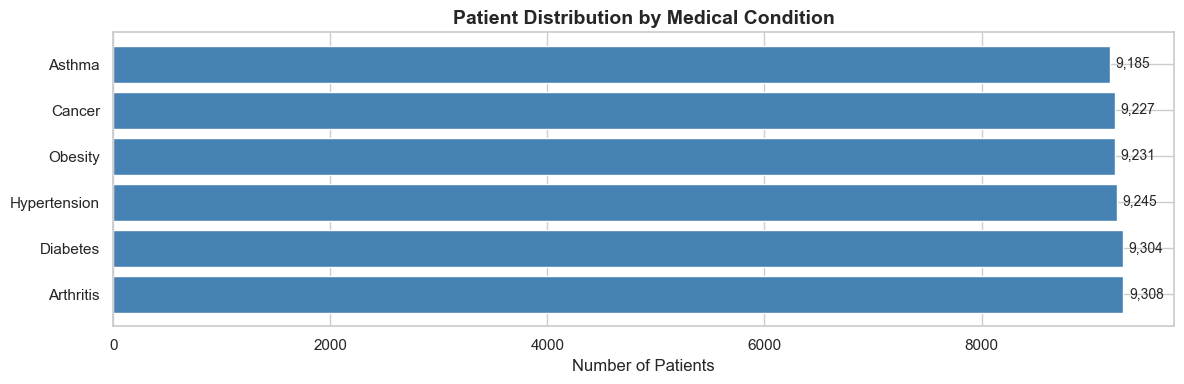

In [9]:
df_conditions = run_query("""
    SELECT medical_condition, COUNT(*) as patient_count
    FROM patients
    GROUP BY medical_condition
    ORDER BY patient_count DESC
""")

fig, ax = plt.subplots()
bars = ax.barh(df_conditions['medical_condition'],
               df_conditions['patient_count'],
               color='steelblue', edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, df_conditions['patient_count']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_title('Patient Distribution by Medical Condition',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Patients')
plt.tight_layout()
plt.savefig('../images/chart1_conditions.png', dpi=150)
plt.show()

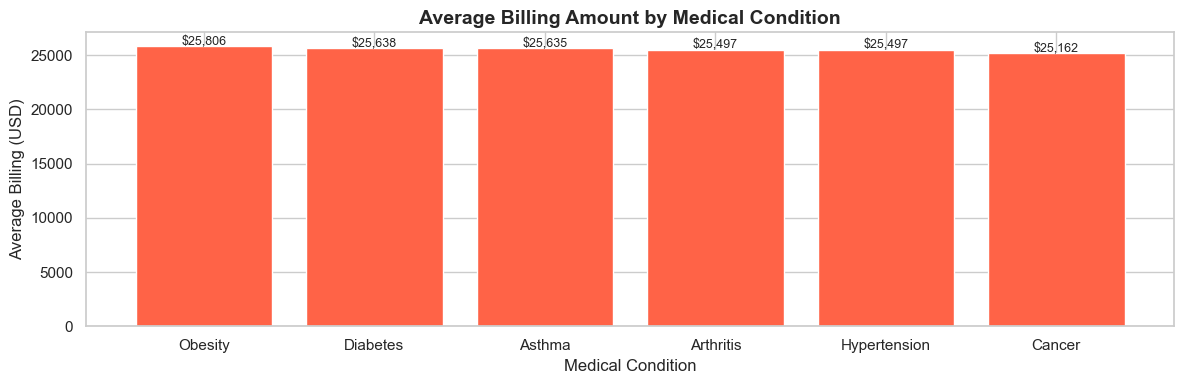

In [10]:
df_billing = run_query("""
    SELECT medical_condition, 
           ROUND(AVG(billing_amount), 2) as avg_billing
    FROM patients
    GROUP BY medical_condition
    ORDER BY avg_billing DESC
""")

fig, ax = plt.subplots()
bars = ax.bar(df_billing['medical_condition'],
              df_billing['avg_billing'],
              color='tomato', edgecolor='white')

# Add value labels on top of bars
for bar, val in zip(bars, df_billing['avg_billing']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'${val:,.0f}', ha='center', fontsize=9)

ax.set_title('Average Billing Amount by Medical Condition',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Medical Condition')
ax.set_ylabel('Average Billing (USD)')
plt.tight_layout()
plt.savefig('../images/chart2_billing.png', dpi=150)
plt.show()

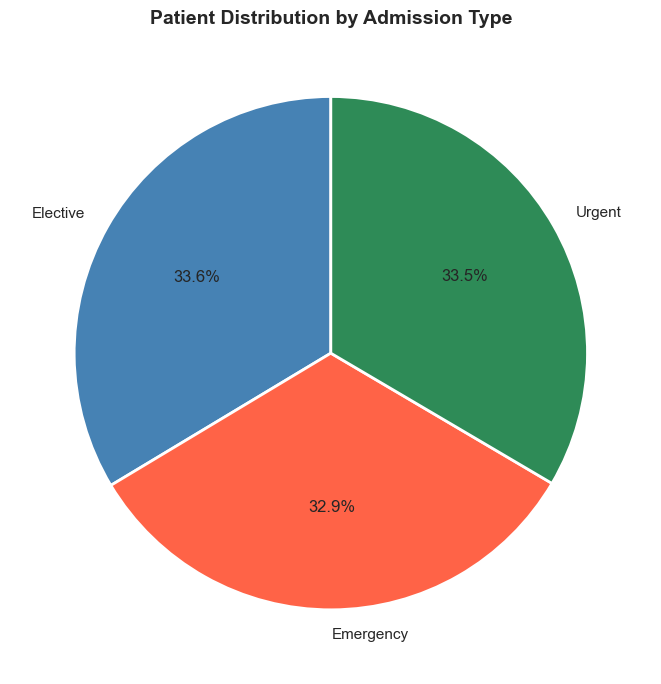

In [11]:
df_admission = run_query("""
    SELECT admission_type, COUNT(*) as count
    FROM patients
    GROUP BY admission_type
""")

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(df_admission['count'],
       labels=df_admission['admission_type'],
       autopct='%1.1f%%',
       colors=['steelblue', 'tomato', 'seagreen'],
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})

ax.set_title('Patient Distribution by Admission Type',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/chart3_admission.png', dpi=150)
plt.show()

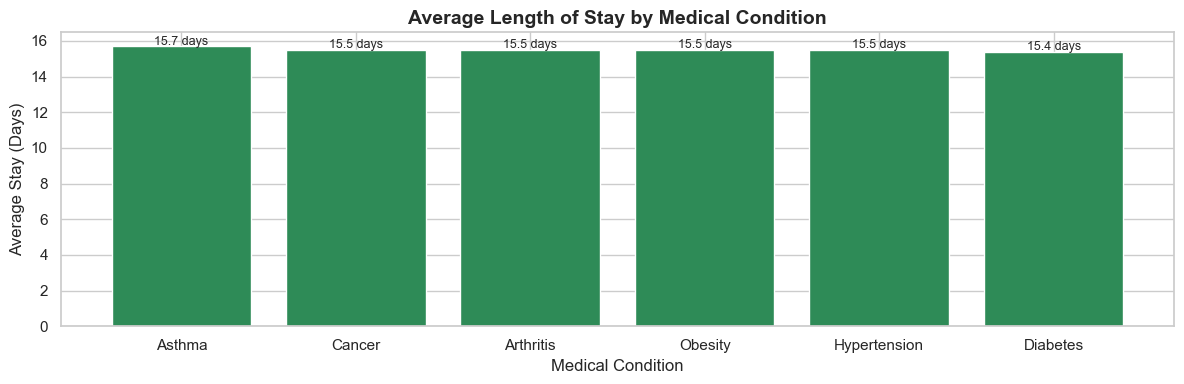

In [12]:
df_stay = run_query("""
    SELECT medical_condition,
           ROUND(AVG(DATEDIFF(discharge_date, date_of_admission)), 1) as avg_stay
    FROM patients
    GROUP BY medical_condition
    ORDER BY avg_stay DESC
""")

fig, ax = plt.subplots()
bars = ax.bar(df_stay['medical_condition'],
              df_stay['avg_stay'],
              color='seagreen', edgecolor='white')

for bar, val in zip(bars, df_stay['avg_stay']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val} days', ha='center', fontsize=9)

ax.set_title('Average Length of Stay by Medical Condition',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Medical Condition')
ax.set_ylabel('Average Stay (Days)')
plt.tight_layout()
plt.savefig('../images/chart4_stay.png', dpi=150)
plt.show()